# Function of the generator

To be able to have more control over the shape of the resulting curve, the generator limits itself to chaining cubic bezier curves.

![bezier chaining](assets/function.png "Bezier Chaining")


In [10]:
import sys
# to be able to import form the upper directories
sys.path.append("..")

# imports
import matplotlib.pyplot as plt

from puzzle_solver.model.point import Point
from puzzle_solver.test_data.generator.generator import Generator
from puzzle_solver.test_data.generator.edge_generator import generate_edge_between

import random
random.seed(1)

In [11]:
# Constant definitions

rows = 5
cols = 7


In [12]:
from typing import Protocol, Union

class Drawable(Protocol):
    def get_points(self) -> list[Point]:
        ...

def draw_points(drawable: Union[Drawable, list[Drawable]]):
    drawables = drawable if isinstance(drawable, list) else [drawable]
    
    points: list[Point] = []
    for d in drawables:
        points += d.get_points()

    points_x = [point.x for point in points]
    points_y = [point.y for point in points]
    plt.scatter(points_x, points_y)

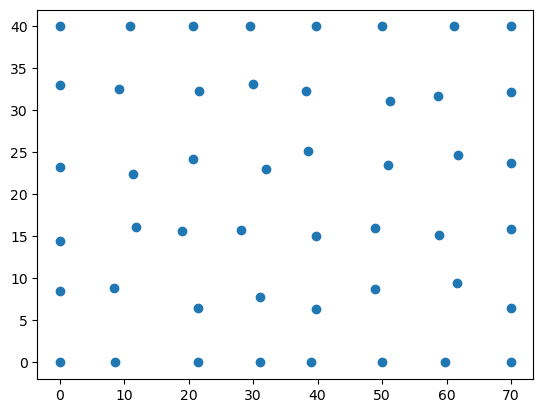

In [13]:
corners = Generator(rows, cols).generate_corners()

corners_x = [[corner.x for corner in row] for row in corners]
corners_y = [[corner.y for corner in row] for row in corners]

plt.scatter(corners_x, corners_y)

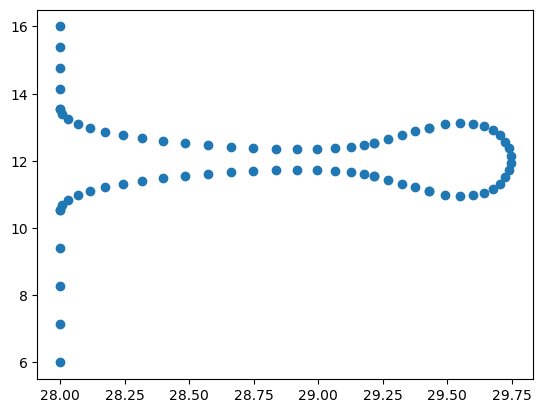

In [14]:
edge = generate_edge_between(Point(28, 6), Point(28, 16), True)
draw_points(edge)


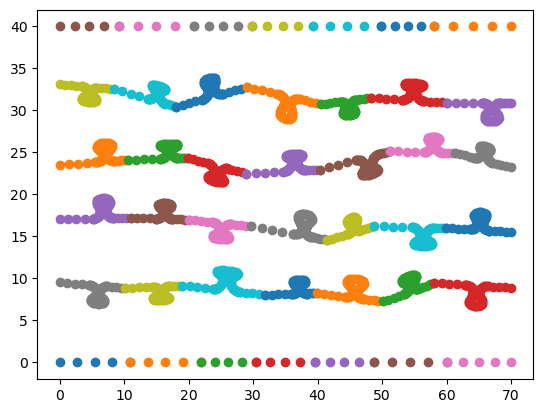

In [15]:
generator = Generator(rows, cols)
corners = generator.generate_corners()
edges_h = generator.generate_horizontal_edges(corners)
#edges_v = generator.generate_vertical_edges(corners)

for row in edges_h:
    for edge in row:
        draw_points(edge)

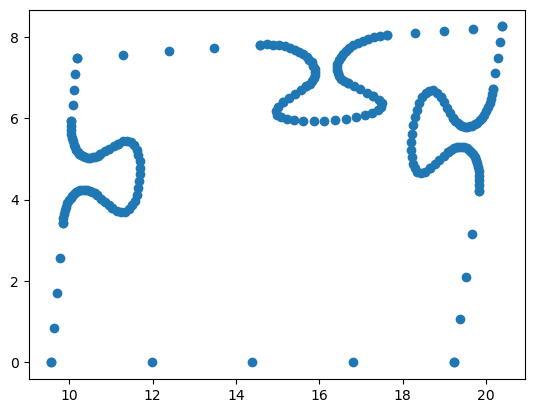

In [16]:
puzzle = Generator(rows, cols).generate()
draw_points(puzzle.pieces[1])

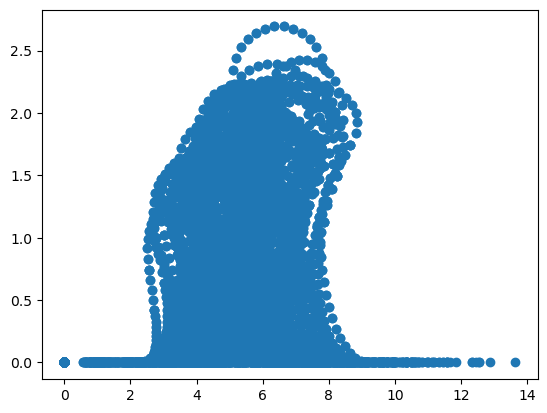

In [17]:

puzzle = Generator(rows, cols).generate()
puzzle.shuffle()
puzzle.normalize()
draw_points(puzzle)
